# Perform hit calling with validation plate

This notebook applies the same thresholds for validation as the original drug screen.

> Note: Code is adapted from Weishan Li.

In [1]:
import pathlib

import pandas as pd


In [2]:
logit_inference_dir = pathlib.Path(".") / "inference_results"
if not logit_inference_dir.exists():
    raise FileNotFoundError(f"Logit inference directory not found: {logit_inference_dir}")

datasplit_dir = pathlib.Path(".") / "datasplits"
if not datasplit_dir.exists():
    raise FileNotFoundError(f"Datasplit directory not found: {datasplit_dir}")

map_file = pathlib.Path(".") / "mAP_scores" / "map_scores.parquet"
if not map_file.exists():
    raise FileNotFoundError(f"mAP scores file not found: {map_file}")

output_dir = pathlib.Path(".") / "hit_calling_results"
output_dir.mkdir(exist_ok=True, parents=True)


In [3]:
treatment_well_file = logit_inference_dir / "treatment_well.csv"
treatment_wells = pd.read_csv(treatment_well_file)
all_treatments = treatment_wells.loc[
    :, ["treatment"]
].drop_duplicates().rename(columns={"treatment": "Metadata_treatment"})
all_treatments = all_treatments[~all_treatments["Metadata_treatment"].isin(["TGFRi"])]
all_treatments.head()


,Metadata_treatment
0,J0337
1,J0899
2,J0528
3,J0375
4,J0093


In [4]:
score_df = pd.read_parquet(logit_inference_dir / "all_logit_scores.parquet")
mean_logit_score = (
    score_df.groupby("Metadata_treatment", as_index=False)["mean_score"]
    .mean()
    .rename(columns={"mean_score": "mean_logit_score"})
)

control_counts_df = pd.read_csv(datasplit_dir / "control_cell_counts.csv")
treated_counts_df = pd.read_csv(datasplit_dir / "cell_counts.csv")

# Robust per-plate baseline from all DMSO control wells (failing + nonfailing)
control_summary = control_counts_df.groupby("Metadata_Plate", as_index=False).agg(
    control_median=("row_count", "median")
)

treated_counts_aug = treated_counts_df.merge(control_summary, on="Metadata_Plate", how="left")
treated_counts_aug["relative_cell_count"] = (
    treated_counts_aug["row_count"] / treated_counts_aug["control_median"]
)

mean_relative_cell_count = (
    treated_counts_aug.groupby("Metadata_treatment", as_index=False)["relative_cell_count"]
    .mean()
    .rename(columns={"relative_cell_count": "mean_relative_cell_count"})
)

logit_inference = mean_logit_score.merge(mean_relative_cell_count, on="Metadata_treatment", how="left")
logit_inference.head()


,Metadata_treatment,mean_logit_score,mean_relative_cell_count
0,J0093,0.598289,0.631707
1,J0337,0.657532,0.458537
2,J0375,0.365296,0.898780
3,J0391,0.872689,0.559756
4,J0406,0.179773,0.498780


In [5]:
map_scores = pd.read_parquet(map_file)
map_scores.head()


,Metadata_treatment,Metadata_reference_index,mean_average_precision,indices,mean_normalized_average_precision,p_value,corrected_p_value,below_p,below_corrected_p
0,DMSO_nonfailing,-1,1.000000,"[0, 3, 6, 9]",1.000000,0.000999,0.001998,True,True
1,J0093,-1,1.000000,"[7, 30, 35, 42]",1.000000,0.000999,0.001998,True,True
2,J0337,-1,1.000000,"[1, 20, 39, 43]",1.000000,0.000999,0.001998,True,True
3,J0375,-1,0.979167,"[5, 27, 33, 47]",0.950365,0.028971,0.045066,True,True
4,J0391,-1,0.904762,"[8, 12, 16, 48]",0.773096,0.051948,0.072727,False,False


In [6]:
all_scores = pd.merge(
    logit_inference,
    map_scores,
    how="outer",
    on="Metadata_treatment",
)
all_scores = pd.merge(
    all_scores,
    all_treatments,
    how="outer",
    on="Metadata_treatment",
)

all_scores.to_csv(output_dir / "score_for_hit_calling.csv", index=False)

all_scores


,Metadata_treatment,mean_logit_score,mean_relative_cell_count,Metadata_reference_index,mean_average_precision,indices,mean_normalized_average_precision,p_value,corrected_p_value,below_p,below_corrected_p
0,DMSO_nonfailing,NaN,NaN,-1,1.000000,"[0, 3, 6, 9]",1.000000,0.000999,0.001998,True,True
1,J0093,0.598289,0.631707,-1,1.000000,"[7, 30, 35, 42]",1.000000,0.000999,0.001998,True,True
2,J0337,0.657532,0.458537,-1,1.000000,"[1, 20, 39, 43]",1.000000,0.000999,0.001998,True,True
3,J0375,0.365296,0.898780,-1,0.979167,"[5, 27, 33, 47]",0.950365,0.028971,0.045066,True,True
4,J0391,0.872689,0.559756,-1,0.904762,"[8, 12, 16, 48]",0.773096,0.051948,0.072727,False,False
5,J0406,0.179773,0.498780,-1,0.933333,"[14, 34, 41, 46]",0.841167,0.028971,0.045066,True,True
6,J0473,0.159077,0.773171,-1,0.730159,"[22, 24, 51, 54]",0.357104,0.199800,0.254291,False,False
7,J0476,0.449697,0.615854,-1,0.601190,"[11, 19, 44, 50]",0.049838,0.385614,0.385614,False,False
8,J0528,0.439757,0.803659,-1,1.000000,"[4, 29, 31, 37]",1.000000,0.000999,0.001998,True,True
9,J0653,0.289143,0.747561,-1,1.000000,"[18, 25, 38, 40]",1.000000,0.000999,0.001998,True,True


In [7]:
RELATIVE_COUNT_THRESHOLD = 0.8
LOGIT_THRESHOLD = 0.9
MAP_THRESHOLD = 0.05

threshold_file = output_dir / "hit_calling_thresholds.txt"
with open(threshold_file, "w") as f:
    f.write(f"RELATIVE_COUNT_THRESHOLD: {RELATIVE_COUNT_THRESHOLD}\n")
    f.write(f"LOGIT_THRESHOLD: {LOGIT_THRESHOLD}\n")
    f.write(f"MAP_THRESHOLD: {MAP_THRESHOLD}\n")

hits_df = all_scores.loc[
    (all_scores["mean_relative_cell_count"] >= RELATIVE_COUNT_THRESHOLD)
    & (all_scores["mean_logit_score"] >= LOGIT_THRESHOLD)
    & (all_scores["corrected_p_value"] <= MAP_THRESHOLD)
].copy()
print(f"Number of hits identified: {hits_df.shape[0]}")
hits_df.head()


Number of hits identified: 0


,Metadata_treatment,mean_logit_score,mean_relative_cell_count,Metadata_reference_index,mean_average_precision,indices,mean_normalized_average_precision,p_value,corrected_p_value,below_p,below_corrected_p


/tmp/ipykernel_873196/2915899558.py:134: UserWarning: You passed a edgecolor/edgecolors ('0.35') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


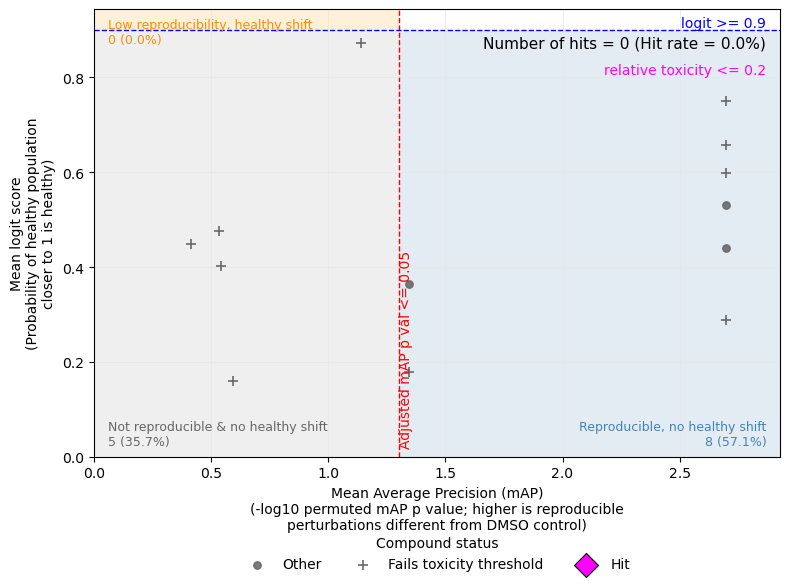

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

plot_dir = output_dir / "plots"
plot_dir.mkdir(exist_ok=True, parents=True)

plot_df = all_scores.copy()
plot_df["neg_log10_p_value"] = -np.log10(plot_df["corrected_p_value"])

map_threshold = -np.log10(MAP_THRESHOLD)
logit_threshold = LOGIT_THRESHOLD
cell_count_threshold = RELATIVE_COUNT_THRESHOLD

significant = (
    (plot_df["neg_log10_p_value"] >= map_threshold)
    & (plot_df["mean_logit_score"] >= logit_threshold)
    & (plot_df["mean_relative_cell_count"] >= cell_count_threshold)
)
plot_df["point_status"] = np.select(
    [significant, plot_df["mean_relative_cell_count"] < cell_count_threshold],
    ["Hit", "Fails toxicity threshold"],
    default="Other",
)

n_hits = int(significant.sum())
n_total = len(plot_df)
hit_rate = round(n_hits / n_total * 100, 1)

n_ll = int(
    (
        (plot_df["neg_log10_p_value"] < map_threshold)
        & (plot_df["mean_logit_score"] < logit_threshold)
    ).sum()
)
n_lr = int(
    (
        (plot_df["neg_log10_p_value"] >= map_threshold)
        & (plot_df["mean_logit_score"] < logit_threshold)
    ).sum()
)
n_tl = int(
    (
        (plot_df["neg_log10_p_value"] < map_threshold)
        & (plot_df["mean_logit_score"] >= logit_threshold)
    ).sum()
)


def pct(n):
    return f"{n} ({round(n / n_total * 100, 1)}%)"


fig, ax = plt.subplots(figsize=(8, 6))
ax.set_facecolor("white")
ax.grid(True, linestyle="-", linewidth=0.5, color="0.9", zorder=0)

x_vals = plot_df["neg_log10_p_value"]
y_vals = plot_df["mean_logit_score"]
x_min, x_max = np.nanmin(x_vals), np.nanmax(x_vals)
y_min, y_max = np.nanmin(y_vals), np.nanmax(y_vals)
x_pad = (x_max - x_min) * 0.1 or 1
y_pad = (y_max - y_min) * 0.1 or 0.1
xlim = (min(x_min - x_pad, 0), x_max + x_pad)
ylim = (min(y_min - y_pad, 0), y_max + y_pad)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Quadrant shading: not-reproducible/no-shift, reproducible/no-shift, low-reproducibility/shift
ax.add_patch(
    Rectangle(
        (xlim[0], ylim[0]),
        map_threshold - xlim[0],
        logit_threshold - ylim[0],
        facecolor="0.8",
        alpha=0.3,
        linewidth=0,
        zorder=0,
    )
)
ax.add_patch(
    Rectangle(
        (map_threshold, ylim[0]),
        xlim[1] - map_threshold,
        logit_threshold - ylim[0],
        facecolor="steelblue",
        alpha=0.15,
        linewidth=0,
        zorder=0,
    )
)
ax.add_patch(
    Rectangle(
        (xlim[0], logit_threshold),
        map_threshold - xlim[0],
        ylim[1] - logit_threshold,
        facecolor="orange",
        alpha=0.15,
        linewidth=0,
        zorder=0,
    )
)

marker_specs = {
    "Other": {
        "marker": "o",
        "facecolor": "0.35",
        "edgecolor": "0.35",
        "alpha": 0.8,
        "s": 30,
        "linewidths": 0.8,
    },
    "Fails toxicity threshold": {
        "marker": "+",
        "facecolor": "0.35",
        "edgecolor": "0.35",
        "alpha": 0.9,
        "s": 45,
        "linewidths": 1.2,
    },
    "Hit": {
        "marker": "D",
        "facecolor": "magenta",
        "edgecolor": "black",
        "alpha": 1.0,
        "s": 150,
        "linewidths": 0.8,
    },
}

for status in ["Other", "Fails toxicity threshold", "Hit"]:
    subset = plot_df[plot_df["point_status"] == status]
    spec = marker_specs[status]
    ax.scatter(
        subset["neg_log10_p_value"],
        subset["mean_logit_score"],
        marker=spec["marker"],
        facecolors=spec["facecolor"],
        edgecolors=spec["edgecolor"],
        alpha=spec["alpha"],
        s=spec["s"],
        linewidths=spec["linewidths"],
        label=status,
        zorder=2,
    )

ax.axvline(map_threshold, color="red", linestyle="--", linewidth=1, zorder=1)
ax.axhline(logit_threshold, color="blue", linestyle="--", linewidth=1, zorder=1)

ax.text(
    0.02,
    0.02,
    f"Not reproducible & no healthy shift\n{pct(n_ll)}",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=9,
    color="0.4",
)
ax.text(
    0.98,
    0.02,
    f"Reproducible, no healthy shift\n{pct(n_lr)}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color="steelblue",
)
ax.text(
    0.02,
    0.98,
    f"Low reproducibility, healthy shift\n{pct(n_tl)}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    color="darkorange",
)

ax.text(
    map_threshold,
    0.02,
    "Adjusted mAP p val <= 0.05",
    transform=ax.get_xaxis_transform(),
    color="red",
    rotation=90,
    ha="left",
    va="bottom",
    fontsize=10,
)
ax.text(
    0.98,
    logit_threshold,
    f"logit >= {LOGIT_THRESHOLD}",
    transform=ax.get_yaxis_transform(),
    color="blue",
    ha="right",
    va="bottom",
    fontsize=10,
)

toxicity_threshold = round(1 - RELATIVE_COUNT_THRESHOLD, 2)
ax.text(
    0.98,
    0.88,
    f"relative toxicity <= {toxicity_threshold}",
    transform=ax.transAxes,
    color="magenta",
    ha="right",
    va="top",
    fontsize=10,
)
ax.text(
    0.98,
    0.94,
    f"Number of hits = {n_hits} (Hit rate = {hit_rate}%)",
    transform=ax.transAxes,
    color="black",
    ha="right",
    va="top",
    fontsize=11,
)

ax.set_xlabel(
    "Mean Average Precision (mAP)\n"
    "(-log10 permuted mAP p value; higher is reproducible\n"
    "perturbations different from DMSO control)"
)
ax.set_ylabel(
    "Mean logit score\n"
    "(Probability of healthy population\n"
    "closer to 1 is healthy)"
)

ax.legend(
    title="Compound status",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,
)

fig.tight_layout()
fig.savefig(plot_dir / "hit_calling_2d.png", dpi=300, bbox_inches="tight")
plt.show()
